In [ ]:
from google.colab import files
uploaded = files.upload()


Grayscale Image


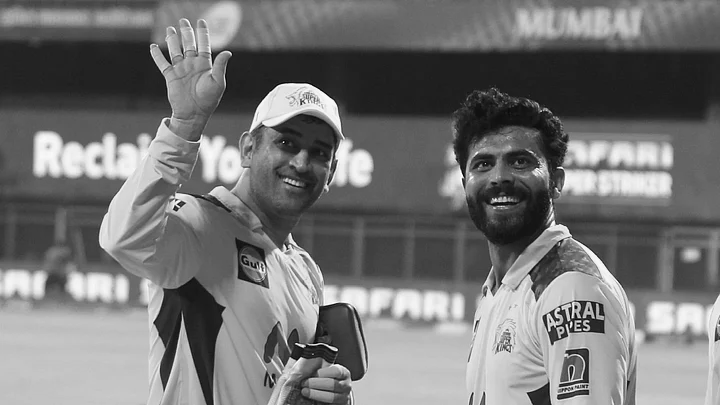

Blur Image


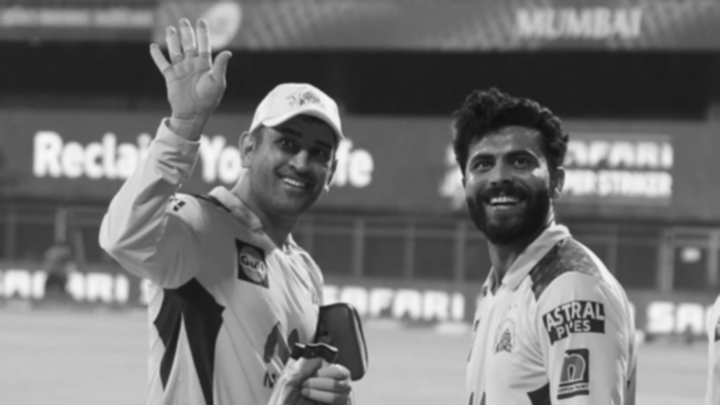

Edge Detection


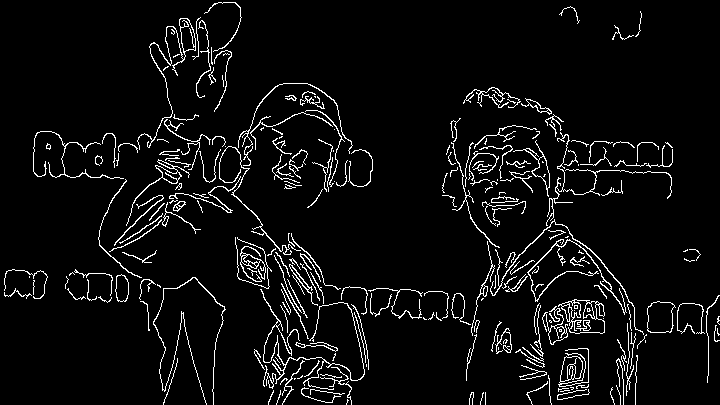

Final Output


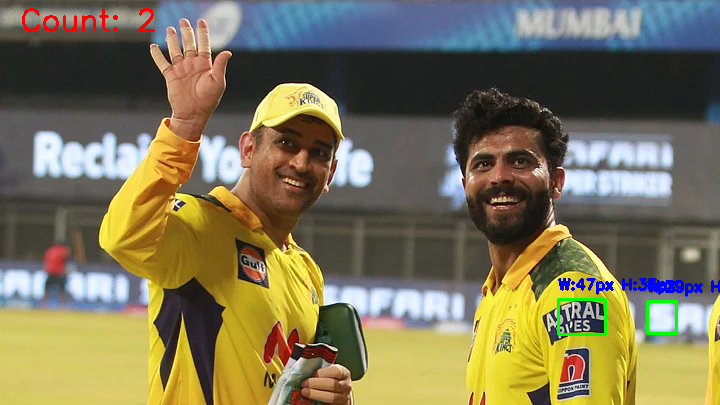

Total Objects: 2
Inference Time: 0.17482495307922363


In [6]:
import cv2
import numpy as np
import time
from google.colab.patches import cv2_imshow
image = cv2.imread("/content/jmsd.webp")
if image is None:
    raise Exception("Image not found. Check path or format!")
orig = image.copy()
start_time = time.time()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print("Grayscale Image")
cv2_imshow(gray)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
print("Blur Image")
cv2_imshow(blur)
edges = cv2.Canny(blur, 50, 150)
print("Edge Detection")
cv2_imshow(edges)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
count = 0
for cnt in contours:
    if cv2.contourArea(cnt) > 500:
        count += 1

        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(orig, (x, y), (x+w, y+h), (0,255,0), 2)

        cv2.putText(orig, f"W:{w}px H:{h}px", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

cv2.putText(orig, f"Count: {count}", (20, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

print("Final Output")
cv2_imshow(orig)

end_time = time.time()

print("Total Objects:", count)
print("Inference Time:", end_time - start_time)

1. Grayscale Image


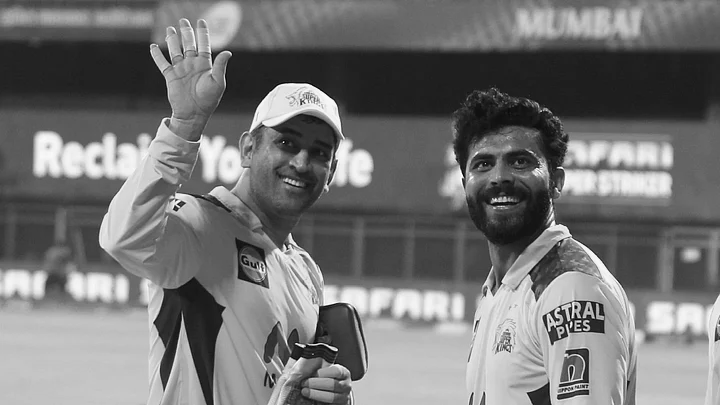

2. Equalized Image


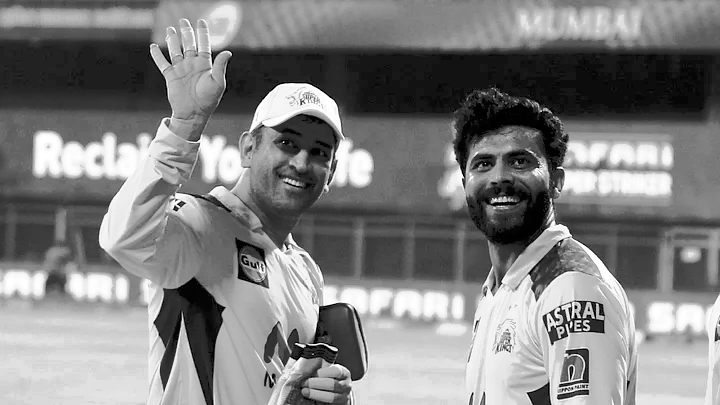

3. Final Detection Output


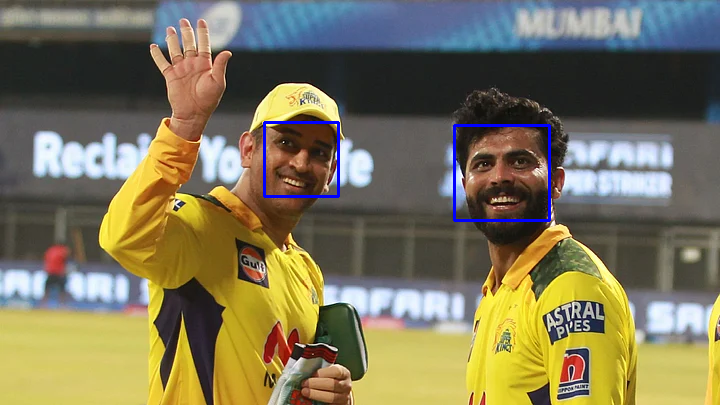

Faces detected: 2
Inference Time: 0.35017824172973633


In [8]:
import cv2
import time
from google.colab.patches import cv2_imshow

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
image = cv2.imread("/content/jmsd.webp")
if image is None:
    raise Exception("Image not found!")
orig = image.copy()
start_time = time.time()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print("1. Grayscale Image")
cv2_imshow(gray)

equalized = cv2.equalizeHist(gray)
print("2. Equalized Image")
cv2_imshow(equalized)

faces = face_cascade.detectMultiScale(
    equalized,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    cv2.rectangle(orig, (x, y), (x+w, y+h), (255, 0, 0), 2)
print("3. Final Detection Output")
cv2_imshow(orig)
end_time = time.time()
print("Faces detected:", len(faces))
print("Inference Time:", end_time - start_time)